In [11]:
from nba_api.stats.endpoints import playergamelogs
import pandas as pd

# Reusing your standard player log query pattern

base_logs = playergamelogs.PlayerGameLogs(
    season_nullable="2024-25",
    season_type_nullable="Regular Season"
)
base_df = base_logs.get_data_frames()[0]
 
advanced_logs = playergamelogs.PlayerGameLogs(
    season_nullable="2024-25",
    season_type_nullable="Regular Season",
    measure_type_player_game_logs_nullable="Advanced"
)
advanced_df = advanced_logs.get_data_frames()[0]

combined_df = pd.merge(
    base_df, 
    advanced_df[['GAME_ID', 'PLAYER_ID', 'USG_PCT']], # Keep only the lookup columns
    on=['GAME_ID', 'PLAYER_ID'], 
    how='inner'
)


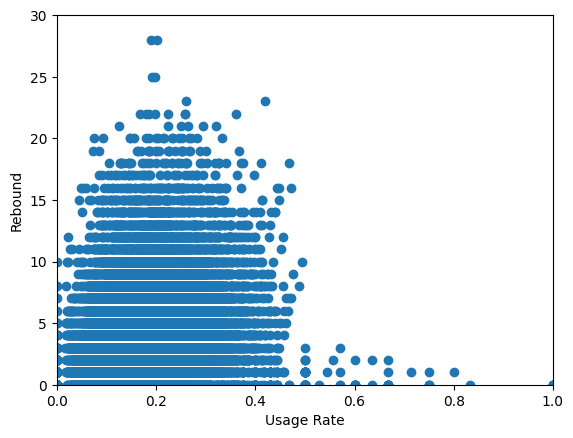

Correlation 0.18774665050895176
R2 0.03524880477733061


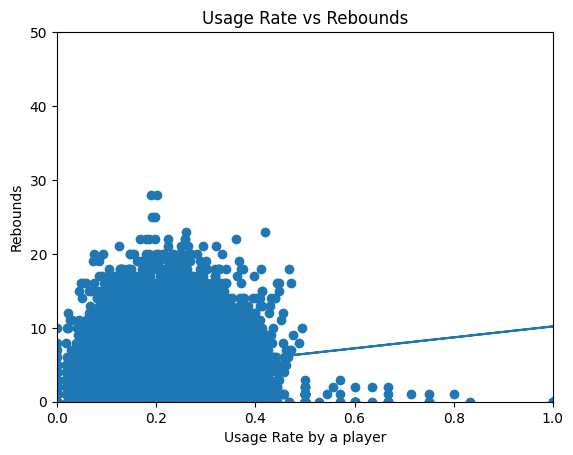

In [13]:
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt


usg_pct_reb = combined_df[["USG_PCT", "REB"]]





plt.scatter(usg_pct_reb["USG_PCT"],usg_pct_reb["REB"])
plt.xlim(0, 1)
plt.ylim(0, 30)
plt.xlabel("Usage Rate")
plt.ylabel("Rebound")
plt.show()
print("Correlation", usg_pct_reb["USG_PCT"].corr(usg_pct_reb["REB"]))

X= usg_pct_reb[["USG_PCT"]]
y = usg_pct_reb["REB"]
model = LinearRegression()
model.fit(X, y)
r2 = model.score(X, y)
print("R2",r2)
predictions = model.predict(X)
plt.scatter(usg_pct_reb["USG_PCT"], usg_pct_reb["REB"])

plt.plot(usg_pct_reb["USG_PCT"], predictions)

plt.xlim(0, 1)
plt.ylim(0, 50)

plt.xlabel("Usage Rate by a player")
plt.ylabel("Rebounds")
plt.title("Usage Rate vs Rebounds")

plt.show()




<Figure size 1000x600 with 0 Axes>

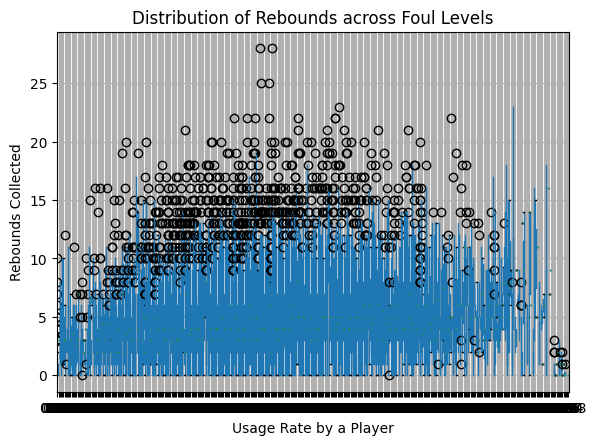

In [31]:
plt.figure(figsize=(10, 6))

# Use the built-in pandas boxplot engine grouped by your player fouls column
# 'column' is your target Y-axis, 'by' splits the data into the 0-6 columns on the X-axis
usg_pct_reb.boxplot(column="REB", by="USG_PCT")

# Clean up formatting titles and display
plt.title("Distribution of Rebounds across Foul Levels")
plt.suptitle("") # Clears out the default automatic pandas title layout
plt.xlabel("Usage Rate by a Player")
plt.ylabel("Rebounds Collected")
plt.show()

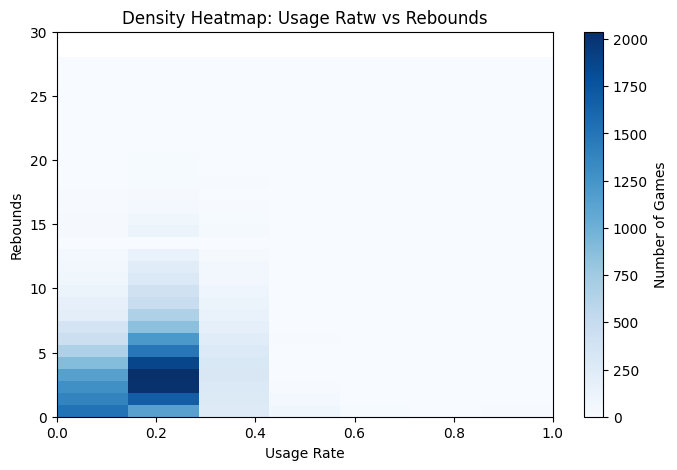

In [ ]:
# Set up your canvas size
plt.figure(figsize=(8, 5))

# Generate a 2D density heatmap
# bins=[7, 30] tells it to split the X-axis into 7 foul blocks and Y-axis into 30 rebound blocks
# cmap="Blues" sets the color gradient (darker blue = more games)
plt.hist2d(usg_pct_reb["USG_PCT"], usg_pct_reb["REB"], bins=[7, 30], cmap="Blues")

# Add a color bar legend to the side showing game counts
plt.colorbar(label="Number of Games")

# Align your axis scales to match your scatter plots
plt.xlim(0, 1)
plt.ylim(0, 30)

plt.xlabel("Usage Rate")
plt.ylabel("Rebounds")
plt.title("Density Heatmap: Usage Ratw vs Rebounds")
plt.show()

In [ ]:
"""Feature: USG_PCT (Usage Percentage)

Relationship: 
Virtually non-existent linear relationship with total REB.

Correlation: 
~0.188

R²: 
~0.035

Why it matters / Basketball Logic: 
Usage rate captures offensive prioritization, not physical positioning. Because 
high-usage guards (low rebounding) and high-usage superstar centers (high rebounding) 
both inhabit the upper tiers of this metric, they blend together into statistical noise.

Pregame usable? 
No, requires historical rolling transformations.

Potential future use: 
Low priority for total rebounds, but highly useful as an interaction term later 
when combined with player position features.
"""